<a href="https://colab.research.google.com/github/sof1a03/Process-Mining/blob/main/question_2/question2_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Filtering rule:**  
We only consider assets with at least 10 total cases (to avoid tiny‐N noise),  
and we require the Wilson 95% CI for the reopen rate to be no wider than 0.3.  
In code, that means:
```python
stable_assets = asset_stats[(asset_stats['total'] >= 10) & (asset_stats['ci_width'] <= 0.3)]


In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statistics
from statsmodels.stats.proportion import proportion_confint
#from pm4py.objects.conversion.log import converter as log_converter

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

Load the CSV with proper parsing

In [3]:
# 1) Load with correct separators & decimals
path = os.path.join(os.getcwd(), "/content/drive/MyDrive/incidentProcess_custom.csv")
data = pd.read_csv(path,
                   sep=";",
                   decimal=",",
                   thousands=".")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303819 entries, 0 to 303818
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Incident ID              303819 non-null  object 
 1   Activity                 303819 non-null  object 
 2   ActivityTimeStamp        303819 non-null  object 
 3   Asset Affected           303819 non-null  object 
 4   Asset Type Affected      303819 non-null  object 
 5   Asset SubType Affected   303819 non-null  object 
 6   Service Affected         303819 non-null  object 
 7   Status                   303819 non-null  object 
 8   Impact                   303819 non-null  int64  
 9   Urgency                  303819 non-null  int64  
 10  Priority                 303819 non-null  int64  
 11  Category                 303819 non-null  object 
 12  Number of Reassignments  303810 non-null  float64
 13  Open Time                303819 non-null  object 
 14  Reop

Label each case as reopened (if any activity has 'Reopen Time'), creating a binary flag

In [4]:
reopened_cases = data[data['Reopen Time'].notna()]['Incident ID'].unique()
data['Reopened'] = data['Incident ID'].isin(reopened_cases).astype(int)

Parse timestamps

In [5]:
data["ActivityTimeStamp"] = pd.to_datetime(
    data["ActivityTimeStamp"],
    infer_datetime_format=True,
    utc=True
)
data["Open Time"]  = pd.to_datetime(data["Open Time"],  dayfirst=True)
data["Close Time"] = pd.to_datetime(data["Close Time"], dayfirst=True)

<ipython-input-5-faf82bcd3eb6>:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data["ActivityTimeStamp"] = pd.to_datetime(


Compute handle time in hours (overwrite unreliable column)

In [6]:
data['computed_handle_hours'] = (data['Close Time'] - data['Open Time']).dt.total_seconds() / 3600
data.drop(columns=['Handle Time (Hours)'], inplace=True)

In [7]:
# data.to_csv("disco_asset_reopen_analysis.csv", index=False)

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303819 entries, 0 to 303818
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Incident ID              303819 non-null  object        
 1   Activity                 303819 non-null  object        
 2   ActivityTimeStamp        303819 non-null  datetime64[ns]
 3   Asset Affected           303819 non-null  object        
 4   Asset Type Affected      303819 non-null  object        
 5   Asset SubType Affected   303819 non-null  object        
 6   Service Affected         303819 non-null  object        
 7   Status                   303819 non-null  object        
 8   Impact                   303819 non-null  int64         
 9   Urgency                  303819 non-null  int64         
 10  Priority                 303819 non-null  int64         
 11  Category                 303819 non-null  object        
 12  Number of Reassi

Reduce to case-level: keep first asset + reopen flag

In [8]:
# Case-level aggregation (keep only relevant columns for each case)
case_df = data.groupby('Incident ID').agg({
    'Reopened': 'max',
    'Asset Caused': 'first',
    'Asset Type Caused': 'first',
    'Asset SubType Caused': 'first',
    'Closure Code': 'first'
}).reset_index()


In [9]:
case_df

,Incident ID,Reopened,Asset Caused,Asset Type Caused,Asset SubType Caused,Closure Code
0,IM0000004,0,SUB000508,subapplication,Web Based Application,Other
1,IM0000005,1,WBA000124,application,Web Based Application,Software
2,IM0000006,0,DTA000024,application,Desktop Application,No error - works as designed
3,IM0000011,0,WBA000124,application,Web Based Application,Operator error
4,IM0000012,0,SUB000508,subapplication,Web Based Application,Other
...,...,...,...,...,...,...
46596,IM0047053,0,SBA000464,application,Server Based Application,Other
46597,IM0047054,0,SBA000461,application,Server Based Application,User error
46598,IM0047055,0,LAP000019,computer,Laptop,Hardware
46599,IM0047056,0,WBA000058,application,Web Based Application,Software


Sanity check: % of reopened incidents

In [10]:
df_reopened = case_df[case_df['Reopened'] == 1]

In [11]:
reopen_pct = case_df['Reopened'].mean() * 100
print(f"Percentage of reopened cases: {reopen_pct:.2f}%")

Percentage of reopened cases: 4.90%


Filter for statistically meaningful assets (≥10 cases)

In [12]:
# Minimum threshold
min_cases = 10

# Count all occurrences
asset_counts = case_df['Asset Caused'].value_counts()
valid_assets = asset_counts[asset_counts >= min_cases].index

# Filter your case-level DataFrame
case_df = case_df[case_df['Asset Caused'].isin(valid_assets)]

Compute per-asset reopen counts, totals, and Wilson CIs

In [13]:
asset_stats = case_df.groupby('Asset Caused')['Reopened'].agg(['sum', 'count']).rename(columns={'sum': 'reopened', 'count': 'total'})
asset_stats['ci_lower'], asset_stats['ci_upper'] = proportion_confint(asset_stats['reopened'], asset_stats['total'], alpha=0.05, method='wilson')
asset_stats['ci_width'] = asset_stats['ci_upper'] - asset_stats['ci_lower']
asset_stats['reopen_rate'] = asset_stats['reopened'] / asset_stats['total']

Filter by confidence width ≤ 0.3 (recommended threshold)

In [14]:
stable_assets = asset_stats[asset_stats['ci_width'] <= 0.3].copy()
stable_assets = stable_assets.sort_values('reopen_rate', ascending=False)

# Show top 10 risky assets (statistically reliable)
print("Top statistically reliable risky assets:")
print(stable_assets.head(10).round(3))

Top statistically reliable risky assets:
              reopened  total  ci_lower  ci_upper  ci_width  reopen_rate
Asset Caused                                                            
WSR000393           23     88     0.181     0.362     0.181        0.261
SAP000004          158    717     0.192     0.252     0.061        0.220
WSR000394           16     95     0.106     0.256     0.150        0.168
SBA000029           11     80     0.079     0.230     0.151        0.138
SAP000005           35    273     0.094     0.173     0.079        0.128
SBA000263          273   2154     0.113     0.141     0.028        0.127
SUB000465            9     74     0.065     0.215     0.150        0.122
SAP000003           11     92     0.068     0.202     0.133        0.120
SUB000521           16    139     0.072     0.179     0.107        0.115
ADB000010           16    141     0.071     0.176     0.105        0.113


LIFT

In [15]:
# Compute LIFT: how much more likely an asset leads to reopen
overall_reopen_rate = case_df['Reopened'].mean()
stable_assets['lift'] = stable_assets['reopen_rate'] / overall_reopen_rate

# Sort by lift
stable_assets = stable_assets.sort_values('lift', ascending=False)

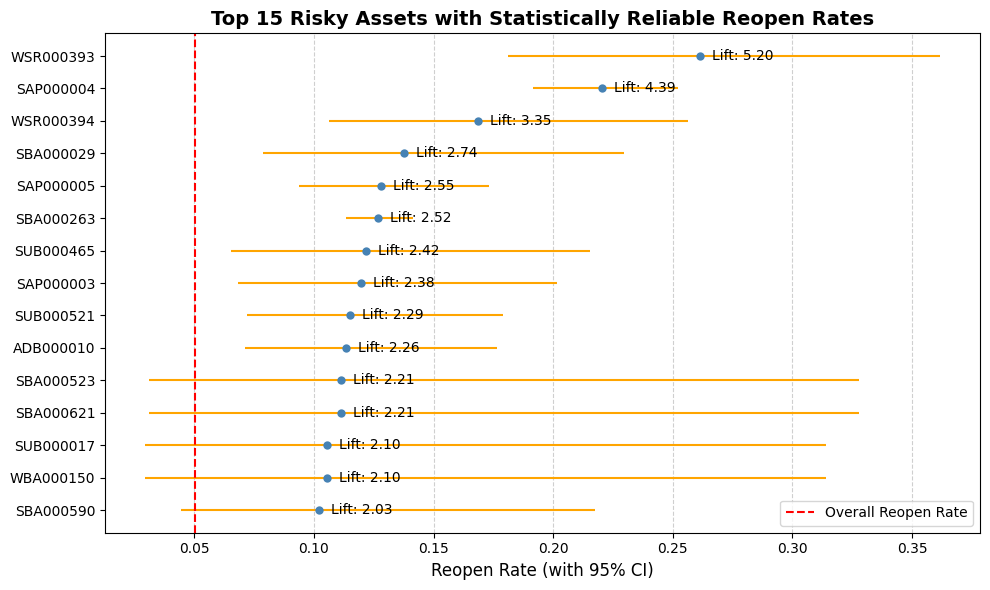

In [16]:
top_n = 15
plot_data = stable_assets.sort_values('reopen_rate', ascending=False).head(top_n)

# Setup
fig, ax = plt.subplots(figsize=(10, 6))

# Data
x = plot_data['reopen_rate']
y = plot_data.index
xerr_low = (x - plot_data['ci_lower']).clip(lower=0)
xerr_high = (plot_data['ci_upper'] - x).clip(lower=0)

# Plot error bars
ax.errorbar(
    x=x,
    y=y,
    xerr=[xerr_low, xerr_high],
    fmt='o',
    color='steelblue',
    ecolor='orange',
    elinewidth=1.5,
    capsize=4,
    markerfacecolor='steelblue',
    markeredgewidth=0
)

# Add lift annotations
for i, (xval, lift) in enumerate(zip(x, plot_data['lift'])):
    ax.text(xval + 0.005, i, f"Lift: {lift:.2f}", va='center', fontsize=10, color='black')

# Vertical baseline for context
ax.axvline(overall_reopen_rate, color='red', linestyle='--', label='Overall Reopen Rate')

# Labels
ax.set_xlabel("Reopen Rate (with 95% CI)", fontsize=12)
ax.set_title("Top 15 Risky Assets with Statistically Reliable Reopen Rates", fontsize=14, weight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
ax.legend()

# Style
plt.tight_layout()
plt.gca().invert_yaxis()  # optional: highest risk at top
plt.show()

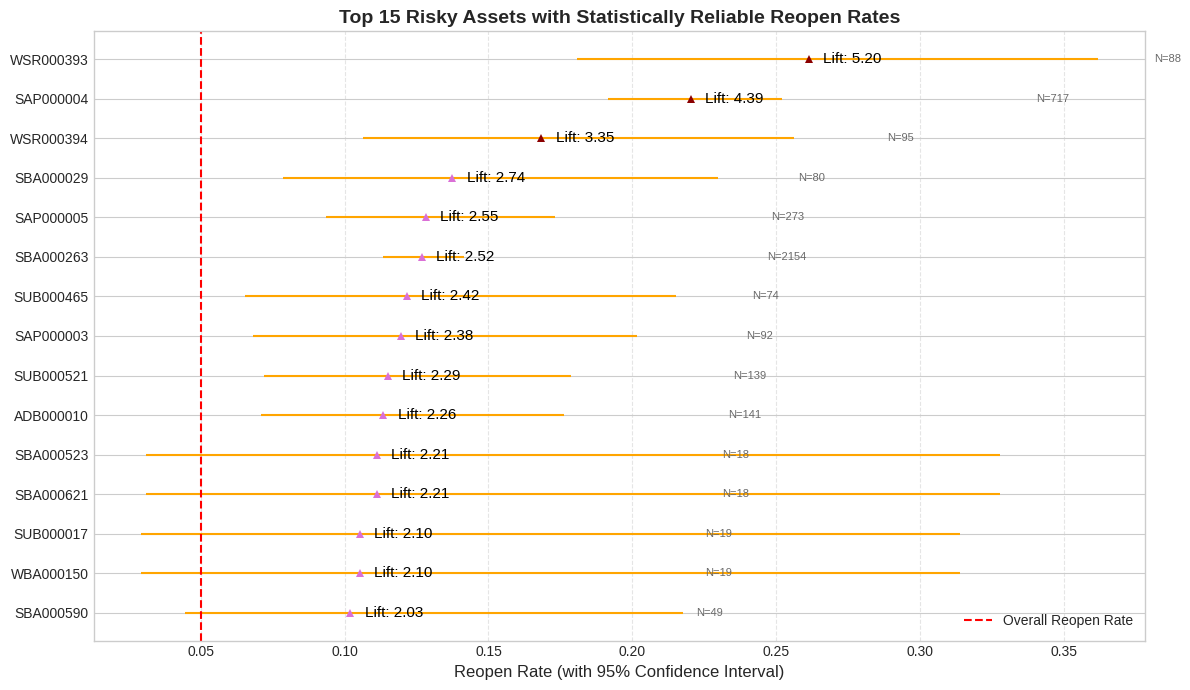

In [17]:
# Apply professional visual style
plt.style.use('seaborn-v0_8-whitegrid')

# Number of top risky assets to show
top_n = 15
plot_data = stable_assets.sort_values('reopen_rate', ascending=False).head(top_n).copy()

# Set up plot
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data
x = plot_data['reopen_rate']
y = plot_data.index
xerr_low = (x - plot_data['ci_lower']).clip(lower=0)
xerr_high = (plot_data['ci_upper'] - x).clip(lower=0)
lift = plot_data['lift']
sample_size = plot_data['total']

# Define color: top 3 in red, rest in blue
colors = ['darkred' if i < 3 else 'orchid' for i in range(len(plot_data))]

# Plot error bars and points
for i, (xval, low, high, color) in enumerate(zip(x, xerr_low, xerr_high, colors)):
    ax.errorbar(
        x=xval,
        y=i,
        xerr=[[low], [high]],
        fmt='^',
        # ecolor='olive',
        ecolor = 'orange',
        color=color,
        capsize=4,
        elinewidth=1.5,
        markerfacecolor=color,
        markeredgewidth=0
    )

# Add lift annotations
for i, (xval, l) in enumerate(zip(x, lift)):
    ax.text(xval + 0.005, i, f"Lift: {l:.2f}", va='center', fontsize=11, color='black')

# sample size annotations
for i, (xval, n) in enumerate(zip(x, sample_size)):
    ax.text(xval + 0.12, i, f"N={n}", va='center', fontsize=8, color='dimgray')

# Add vertical line for overall average
ax.axvline(overall_reopen_rate, color='red', linestyle='--', label='Overall Reopen Rate')

# Formatting
ax.set_yticks(range(len(y)))
ax.set_yticklabels(y)
ax.set_xlabel("Reopen Rate (with 95% Confidence Interval)", fontsize=12)
ax.set_title("Top 15 Risky Assets with Statistically Reliable Reopen Rates", fontsize=14, weight='bold')
ax.invert_yaxis()  # Optional: highest risk at top
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

In [18]:
#subtype analysis
subtype_all = case_df['Asset SubType Caused'].value_counts(normalize=True).rename("All %") * 100
subtype_reopened = df_reopened['Asset SubType Caused'].value_counts(normalize=True).rename("Reopened %") * 100

subtype_comparison = pd.concat([subtype_all, subtype_reopened], axis=1).fillna(0)
subtype_comparison['Lift'] = subtype_comparison['Reopened %'] / subtype_comparison['All %']
subtype_comparison = subtype_comparison.sort_values('Lift', ascending=False)
print(subtype_comparison.head(10).round(2))

                      All %  Reopened %   Lift
Asset SubType Caused                          
Router                 0.00        0.09    inf
VDI                    0.00        0.09    inf
Banking Device         0.00        0.31    inf
MQ Queue Manager       0.00        0.04    inf
X86 Server             0.00        0.04    inf
Thin Client            0.00        0.04    inf
SharePoint Farm        0.00        0.04    inf
Desktop                0.06        1.09  19.89
Printer                0.04        0.18   4.58
Windows Server         0.46        1.88   4.08


In [19]:
# Breakdown by asset TYPE
df_reopened = case_df[case_df['Reopened'] == 1]

type_all = case_df['Asset Type Caused'].value_counts(normalize=True).rename("All %") * 100
type_reopened = df_reopened['Asset Type Caused'].value_counts(normalize=True).rename("Reopened %") * 100

type_comparison = pd.concat([type_all, type_reopened], axis=1).fillna(0)
type_comparison['Lift'] = type_comparison['Reopened %'] / type_comparison['All %']
type_comparison = type_comparison.sort_values('Lift', ascending=False)
print(type_comparison.head(10).round(2))

                   All %  Reopened %  Lift
Asset Type Caused                         
database            0.36        0.76  2.11
computer            1.56        2.53  1.62
officeelectronics   0.19        0.24  1.24
application        68.02       72.32  1.06
software            5.41        5.00  0.92
subapplication     17.72       15.82  0.89
#N/B                2.79        1.43  0.51
storage             2.62        1.33  0.51
hardware            0.85        0.38  0.45
displaydevice       0.32        0.14  0.44


In [20]:
subtype_all = case_df['Asset SubType Caused'].value_counts(normalize=True).rename("All %") * 100
subtype_reopened = df_reopened['Asset SubType Caused'].value_counts(normalize=True).rename("Reopened %") * 100

subtype_comparison = pd.concat([subtype_all, subtype_reopened], axis=1).fillna(0)
subtype_comparison['Lift'] = subtype_comparison['Reopened %'] / subtype_comparison['All %']
subtype_comparison = subtype_comparison.sort_values('Reopened %', ascending=False)

print("------------------------------------------------------\n")
print("Top 10 risky subtypes")
print(subtype_comparison.head(10).round(2))


------------------------------------------------------

Top 10 risky subtypes
                          All %  Reopened %  Lift
Asset SubType Caused                             
Server Based Application  37.56       41.40  1.10
Web Based Application     34.61       29.16  0.84
SAP                        2.62        9.86  3.76
System Software            5.34        4.95  0.93
Desktop Application        7.58        4.91  0.65
Windows Server             0.46        1.86  4.02
#N/B                       2.79        1.43  0.51
Client Based Application   0.96        1.38  1.44
SAN                        2.56        1.29  0.50
Database                   0.36        0.76  2.11


Asset caused

In [21]:
asset_all = case_df['Asset Caused'].value_counts(normalize=True).rename("All %") * 100
asset_reopened = df_reopened['Asset Caused'].value_counts(normalize=True).rename("Reopened %") * 100

asset_comparison = pd.concat([asset_all, asset_reopened], axis=1).fillna(0)
asset_comparison['Lift'] = asset_comparison['Reopened %'] / asset_comparison['All %']
asset_comparison = asset_comparison.sort_values('Reopened %', ascending=False)


Type of asset caused

In [22]:
type_all = case_df['Asset Type Caused'].value_counts(normalize=True).rename("All %") * 100
type_reopened = df_reopened['Asset Type Caused'].value_counts(normalize=True).rename("Reopened %") * 100

type_comparison = pd.concat([type_all, type_reopened], axis=1).fillna(0)
type_comparison['Lift'] = type_comparison['Reopened %'] / type_comparison['All %']
type_comparison = type_comparison.sort_values('Reopened %', ascending=False)


Asset SubType Caused

In [23]:
subtype_all = case_df['Asset SubType Caused'].value_counts(normalize=True).rename("All %") * 100
subtype_reopened = df_reopened['Asset SubType Caused'].value_counts(normalize=True).rename("Reopened %") * 100

subtype_comparison = pd.concat([subtype_all, subtype_reopened], axis=1).fillna(0)
subtype_comparison['Lift'] = subtype_comparison['Reopened %'] / subtype_comparison['All %']
subtype_comparison = subtype_comparison.sort_values('Reopened %', ascending=False)




## 2) Show All Three Comparison Tables (ID, Type, SubType)

In [24]:
print('Top 10 risky assets\n')
print(asset_comparison.head(10).round(2))
print("─" * 60)
print('Top 10 risky asset types')
print(type_comparison.head(10).round(2))
print("─" * 60)
print('Top 10 risky subtypes')
print(subtype_comparison.head(10).round(2))

# Export to Excel (optional)
# with pd.ExcelWriter("asset_reopen_risk_analysis.xlsx") as writer:
#     asset_comparison.to_excel(writer, sheet_name='Asset Caused')
#     type_comparison.to_excel(writer, sheet_name='Asset Type Caused')
#     subtype_comparison.to_excel(writer, sheet_name='Asset SubType Caused')


Top 10 risky assets

              All %  Reopened %  Lift
Asset Caused                         
SBA000263      5.15       13.01  2.52
SAP000004      1.72        7.53  4.39
SBA000607      3.58        6.24  1.74
SUB000456      7.06        5.72  0.81
SBA000462      4.02        4.95  1.23
SSW000101      5.15        4.81  0.93
WBA000133      3.43        3.38  0.99
WBA000011      2.18        2.14  0.98
WBA000144      2.23        2.10  0.94
SUB000424      1.78        1.91  1.07
────────────────────────────────────────────────────────────
Top 10 risky asset types
                   All %  Reopened %  Lift
Asset Type Caused                         
application        68.02       72.32  1.06
subapplication     17.72       15.82  0.89
software            5.41        5.00  0.92
computer            1.56        2.53  1.62
#N/B                2.79        1.43  0.51
storage             2.62        1.33  0.51
database            0.36        0.76  2.11
hardware            0.85        0.38  0.45
officee

# 3) Bar plots: Top 10 Asset Types (by Lift) and Top 10 Asset SubTypes (by Lift)

<ipython-input-25-e414f694a00c>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


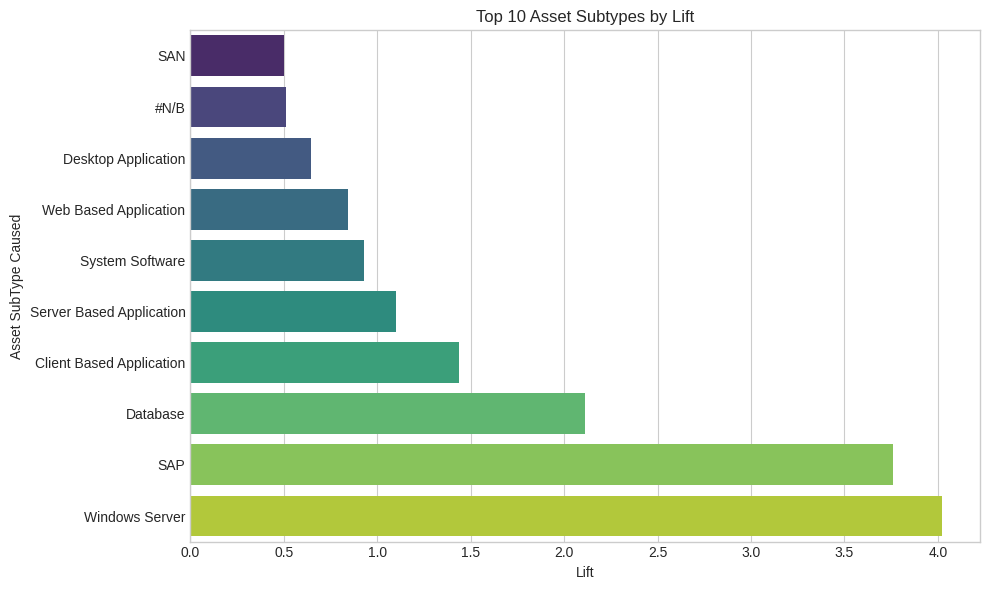

In [25]:
top_subtypes = subtype_comparison.head(10).sort_values('Lift')

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Lift',
    y=top_subtypes.index,
    data=top_subtypes,
    palette='viridis'
)
plt.title("Top 10 Asset Subtypes by Lift")
plt.xlabel("Lift")
plt.ylabel("Asset SubType Caused")
plt.tight_layout()
plt.show()

<ipython-input-26-2d04fdd923aa>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


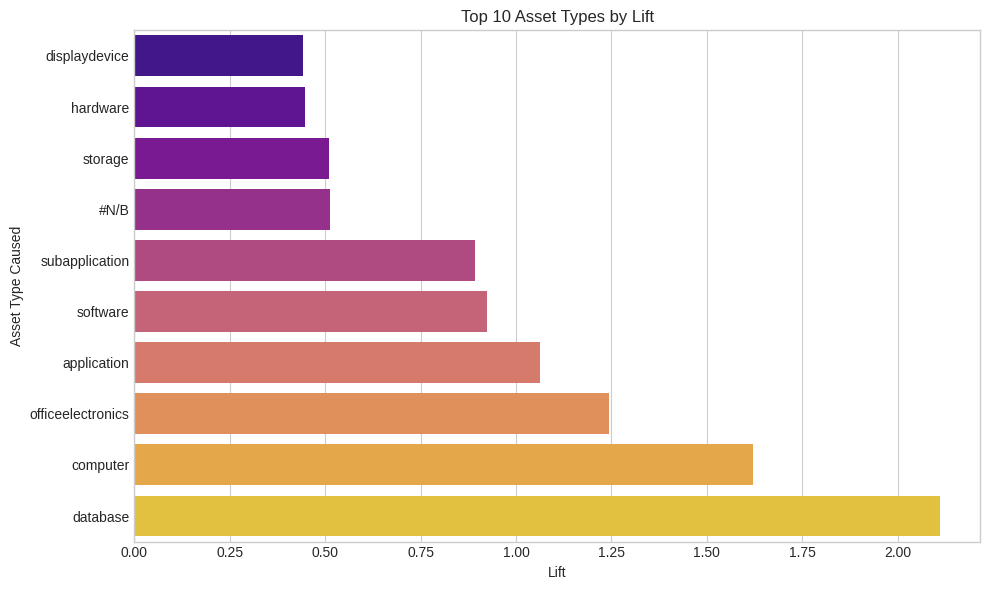

In [26]:
top_types = type_comparison.head(10).sort_values('Lift')

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Lift',
    y=top_types.index,
    data=top_types,
    palette='plasma'
)
plt.title("Top 10 Asset Types by Lift")
plt.xlabel("Lift")
plt.ylabel("Asset Type Caused")
plt.tight_layout()
plt.show()

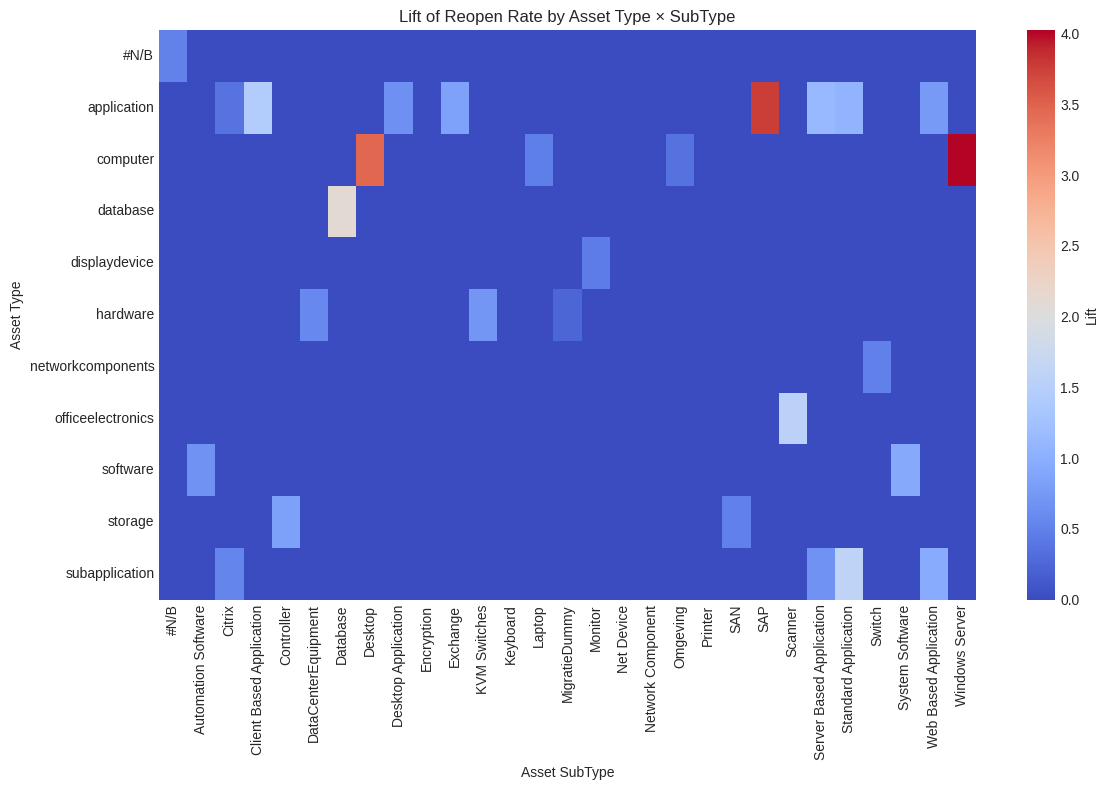

In [27]:
pivot_lift = case_df.groupby(['Asset Type Caused', 'Asset SubType Caused'])['Reopened'].agg(['mean', 'count']).reset_index()
pivot_lift = pivot_lift[pivot_lift['count'] >= 10]
pivot_lift['lift'] = pivot_lift['mean'] / overall_reopen_rate

heatmap_df = pivot_lift.pivot(index='Asset Type Caused', columns='Asset SubType Caused', values='lift').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, cmap="coolwarm", annot=False, fmt=".2f", cbar_kws={'label': 'Lift'})
plt.title("Lift of Reopen Rate by Asset Type × SubType")
plt.xlabel("Asset SubType")
plt.ylabel("Asset Type")
plt.tight_layout()
plt.show()

## Predicting Reopen Risk: Linear Regression and Classification Tree

To complement the statistical analysis of asset-level reopen rates, we now fit two predictive models to estimate the likelihood of a case being reopened based on its technical attributes. These models serve two purposes:

1. **Linear Regression** – While not ideal for binary classification, it provides an interpretable baseline and allows us to assess which features are linearly associated with higher reopen risk.
2. **Classification Tree** – A non-linear, interpretable model that reveals conditional rules (e.g., "if Asset SubType is X and Closure Code is Y, then risk is high").

We use the following features:
- `Asset Caused` (top frequent assets, one-hot encoded)
- `Asset Type Caused`
- `Asset SubType Caused`
- `Closure Code`

We exclude rare values to reduce noise and improve model generalizability.


In [28]:
# Prepare dataset
model_df = case_df.copy()

# Drop NAs
model_df = model_df.dropna(subset=['Asset Caused', 'Asset Type Caused', 'Asset SubType Caused', 'Closure Code'])

# Select top N categories to encode (avoid too many dummies)
top_assets = model_df['Asset Caused'].value_counts().head(10).index
model_df['Asset Caused'] = model_df['Asset Caused'].apply(lambda x: x if x in top_assets else 'Other')

# Same for types and subtypes
top_types = model_df['Asset Type Caused'].value_counts().head(10).index
model_df['Asset Type Caused'] = model_df['Asset Type Caused'].apply(lambda x: x if x in top_types else 'Other')

top_subtypes = model_df['Asset SubType Caused'].value_counts().head(10).index
model_df['Asset SubType Caused'] = model_df['Asset SubType Caused'].apply(lambda x: x if x in top_subtypes else 'Other')

In [29]:
# Features and target
X = model_df[['Asset Caused', 'Asset Type Caused', 'Asset SubType Caused', 'Closure Code']]
y = model_df['Reopened']

# Preprocessing pipeline
categorical_features = X.columns.tolist()
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Linear regression

In [30]:
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)

print("🔍 Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

🔍 Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      7947
           1       0.09      0.46      0.15       414

    accuracy                           0.74      8361
   macro avg       0.53      0.61      0.50      8361
weighted avg       0.92      0.74      0.81      8361



##Classification Tree

In [31]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42))
])

tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

print("🌳 Classification Tree Performance:")
print(classification_report(y_test, y_pred_tree))

🌳 Classification Tree Performance:
              precision    recall  f1-score   support

           0       0.96      0.89      0.93      7947
           1       0.13      0.30      0.18       414

    accuracy                           0.86      8361
   macro avg       0.55      0.60      0.55      8361
weighted avg       0.92      0.86      0.89      8361



In [32]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(random_state=42)

pipeline_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', DecisionTreeClassifier(max_depth=4))
])
pipeline_smote.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Asset Caused',
                                                   'Asset Type Caused',
                                                   'Asset SubType Caused',
                                                   'Closure Code'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', DecisionTreeClassifier(max_depth=4))])

In [33]:
y_pred_tree = pipeline_smote.predict(X_test)

print("SMOTE + decision tree Performance:")
print(classification_report(y_test, y_pred_tree))

SMOTE + decision tree Performance:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7947
           1       0.13      0.30      0.18       414

    accuracy                           0.87      8361
   macro avg       0.55      0.60      0.56      8361
weighted avg       0.92      0.87      0.89      8361



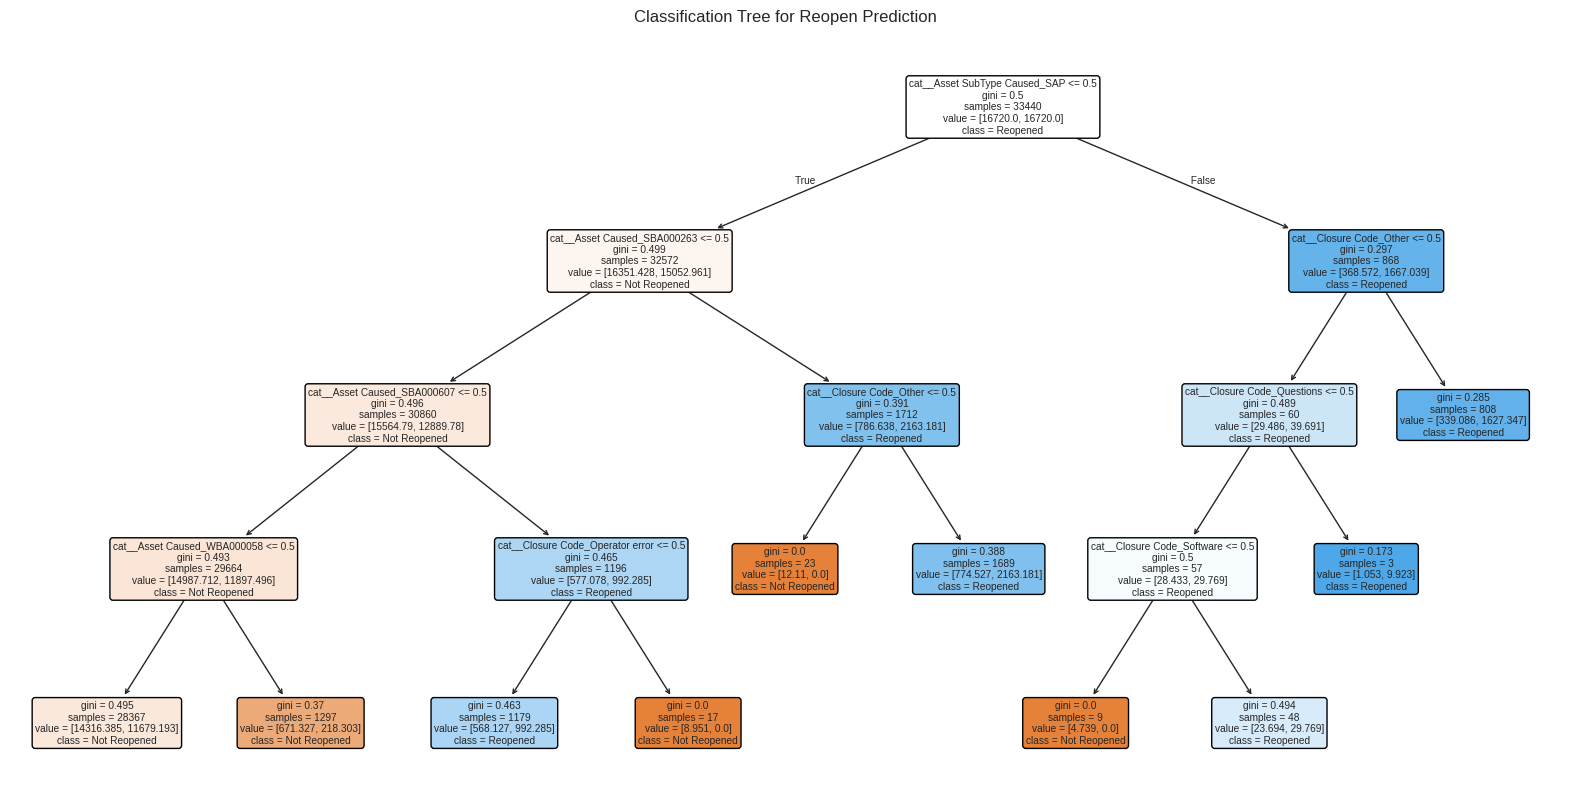

In [34]:
plt.figure(figsize=(20, 10))
feature_names = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()
plot_tree(tree_pipeline.named_steps['classifier'],
          feature_names=feature_names,
          class_names=['Not Reopened', 'Reopened'],
          filled=True,
          rounded=True)
plt.title("Classification Tree for Reopen Prediction")
plt.show()

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303819 entries, 0 to 303818
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   Incident ID              303819 non-null  object             
 1   Activity                 303819 non-null  object             
 2   ActivityTimeStamp        303819 non-null  datetime64[ns, UTC]
 3   Asset Affected           303819 non-null  object             
 4   Asset Type Affected      303819 non-null  object             
 5   Asset SubType Affected   303819 non-null  object             
 6   Service Affected         303819 non-null  object             
 7   Status                   303819 non-null  object             
 8   Impact                   303819 non-null  int64              
 9   Urgency                  303819 non-null  int64              
 10  Priority                 303819 non-null  int64              
 11  Category     

In [36]:
!pip install imbalanced-learn xgboost --quiet

In [54]:
# -*- coding: utf-8 -*-
"""
Comprehensive predictive modeling pipeline for “reopened” incidents.
Includes:
  - Data loading & preprocessing (no drastic row reduction)
  - Feature engineering (including smoothing/target encoding for high‐cardinality assets)
  - Train/test split
  - Logistic Regression
  - Classification Tree
  - Random Forest
  - LSTM on sequence of activities
"""

import os
import numpy as np
import pandas as pd

# === 1. LOAD DATA ===
# Adjust this path to where your CSV sits:
data_path = "/content/drive/MyDrive/incidentProcess_custom.csv"  # e.g., in the same folder as this script/notebook

# The CSV uses ";" as separator and European number formatting:
# The CSV uses ";" as separator and European number formatting:
data = pd.read_csv(
    data_path,
    sep=";",
    decimal=",",
    thousands=".",
    low_memory=False,
)
print(f"Original rows: {len(data)}")  # Expect ~303k rows

# === 2. PARSE TIMESTAMPS & DROP TZ (to avoid naive-vs-aware errors) ===
# We parse with utc=True, then immediately remove the timezone:
data["ActivityTimeStamp"] = (
    pd.to_datetime(data["ActivityTimeStamp"], utc=True, errors="coerce")
    .dt.tz_convert(None)
)

data["Open Time"] = pd.to_datetime(
    data["Open Time"], dayfirst=True, errors="coerce"
)
data["Close Time"] = pd.to_datetime(
    data["Close Time"], dayfirst=True, errors="coerce"
)
data["Reopen Time"] = pd.to_datetime(
    data["Reopen Time"], dayfirst=True, errors="coerce"
)

# Create an event‐level “Reopened” flag (1 if this row has a non‐null Reopen Time):
data["Reopened_Event"] = (~data["Reopen Time"].isna()).astype(int)
data.info()

Original rows: 303819
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303819 entries, 0 to 303818
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Incident ID              303819 non-null  object        
 1   Activity                 303819 non-null  object        
 2   ActivityTimeStamp        303819 non-null  datetime64[ns]
 3   Asset Affected           303819 non-null  object        
 4   Asset Type Affected      303819 non-null  object        
 5   Asset SubType Affected   303819 non-null  object        
 6   Service Affected         303819 non-null  object        
 7   Status                   303819 non-null  object        
 8   Impact                   303819 non-null  int64         
 9   Urgency                  303819 non-null  int64         
 10  Priority                 303819 non-null  int64         
 11  Category                 303819 non-null  object        

In [58]:
# === 3. AGGREGATE TO CASE LEVEL ===
# First, compute any needed intermediate features at the event level:
#   - We’ll want: “is_set_asset_event” and timestamp of first “Set Asset Caused”
#   - activity count per case
#   - number of reassignments per case: if “Number of Reassignments” column exists, use that; else infer.

# If “Number of Reassignments” is already a column, we will use the maximum per Incident ID. Otherwise:
if "Number of Reassignments" not in data.columns:
    # Infer reassignments by counting changes in “Assignment Group” per case
    data.sort_values(["Incident ID", "ActivityTimeStamp"], inplace=True)
    data["prev_assignment"] = data.groupby("Incident ID")["Assignment Group"].shift(1)
    data["is_reassignment"] = (
        (data["Assignment Group"].notna())
        & (data["prev_assignment"].notna())
        & (data["Assignment Group"] != data["prev_assignment"])
    ).astype(int)
    data.drop(columns=["prev_assignment"], inplace=True)
    # We will sum up is_reassignment per case

# Flag the first “Set Asset Caused” event:
data["is_set_asset_event"] = (data["Activity"] == "Set Asset Caused").astype(int)
# Extract timestamp of first “Set Asset Caused”
first_setasset = (
    data[data["is_set_asset_event"] == 1]
    .groupby("Incident ID")["ActivityTimeStamp"]
    .min()
    .rename("first_setasset_time")
)

# Extract timestamp of first “Reopen Time” per case
first_reopen = (
    data[~data["Reopen Time"].isna()]
    .groupby("Incident ID")["Reopen Time"]
    .min()
    .rename("first_reopen_time")
)

# Activity count per case:
activity_count = (
    data.groupby("Incident ID")["Activity"].count().rename("activity_count")
)

# Reopened flag per case:
reopened_flag = data.groupby("Incident ID")["Reopened_Event"].max().rename("Reopened")

# Numeric “handle hours” computed from Open/Close:
data["computed_handle_hours"] = (
    data["Close Time"] - data["Open Time"]
).dt.total_seconds() / 3600.0

# But better to take handle hours at case‐level: (Close Time − Open Time) using min/max per case
# --- After grouping, you have:
case_open = data.groupby("Incident ID")["Open Time"].min().rename("case_open_time")
case_close = data.groupby("Incident ID")["Close Time"].max().rename("case_close_time")
case_handle_hours = ((case_close - case_open).dt.total_seconds() / 3600.0).rename("handle_hours")

# Compute num_reassignments:
if "Number of Reassignments" in data.columns:
    num_reassign = (
        data.groupby("Incident ID")["Number of Reassignments"]
        .max()
        .rename("num_reassignments")
    )
else:
    num_reassign = data.groupby("Incident ID")["is_reassignment"]\
                         .sum().rename("num_reassignments")

# Build first‐seen categoricals, reopened flag, activity_count, etc.
case_first = data.groupby("Incident ID").agg(
    Asset_Caused=("Asset Caused", "first"),
    Asset_Type_Caused=("Asset Type Caused", "first"),
    Asset_SubType_Caused=("Asset SubType Caused", "first"),
    Closure_Code=("Closure Code", "first"),
    Priority=("Priority", "first"),
    Impact=("Impact", "first"),
    Urgency=("Urgency", "first"),
    Category=("Category", "first"),
    Assignment_Group=("Assignment Group", "first"),
)
reopened_flag = data.groupby("Incident ID")["Reopened_Event"].max().rename("Reopened")
activity_count = data.groupby("Incident ID")["Activity"].count().rename("activity_count")

# Timestamps for first_setasset and first_reopen
first_setasset = (
    data[data["Activity"] == "Set Asset Caused"]
    .groupby("Incident ID")["ActivityTimeStamp"]
    .min().rename("first_setasset_time")
)
first_reopen = (
    data[~data["Reopen Time"].isna()]
    .groupby("Incident ID")["Reopen Time"]
    .min().rename("first_reopen_time")
)
delta = ((first_reopen - first_setasset).dt.total_seconds() / 3600.0).rename(
    "delta_setasset_reopen"
)

# Combine into one DataFrame:
case_df = pd.concat(
    [
        case_first,
        reopened_flag,
        activity_count,
        num_reassign,
        case_handle_hours,
        delta,
    ],
    axis=1,
)

# ====== HERE IS THE CRITICAL FIX ======
# Fill that one missing value in num_reassignments (everyone else is complete)
case_df["num_reassignments"] = case_df["num_reassignments"].fillna(0)


# Fill any NaN in delta_setasset_reopen (e.g. never reopened → -1,
# reopened without set_asset → -2)
case_df["delta_setasset_reopen"] = case_df["delta_setasset_reopen"].fillna(-1.0)
mask_no_setasset = (first_setasset.isna()) & (case_df["Reopened"] == 1)
case_df.loc[mask_no_setasset.index[mask_no_setasset], "delta_setasset_reopen"] = -2.0

In [59]:
# === 4. FEATURE ENGINEERING & PREPROCESSING ===
# 4.1. Handle missing values for categorical features—replace NaN with 'Unknown'
cat_cols = [
    "Asset_Caused",
    "Asset_Type_Caused",
    "Asset_SubType_Caused",
    "Closure_Code",
    "Priority",
    "Impact",
    "Urgency",
    "Category",
    "Assignment_Group",
]
case_df[cat_cols] = case_df[cat_cols].fillna("Unknown")

# 4.2. Numeric features: “activity_count”, “num_reassignments”, “handle_hours”, “delta_setasset_reopen”
# For “delta_setasset_reopen”: leave negative codes for “never reopened” or “no set asset” as is; tree‐based models can split on them.

# 4.3. TARGET ENCODING (with smoothing) for “Asset_Caused” (high cardinality)
# Compute global mean of “Reopened”
global_mean = case_df["Reopened"].mean()

# Compute sums and counts per asset
asset_stats = (
    case_df.groupby("Asset_Caused")["Reopened"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "reopened_sum", "count": "asset_count"})
)

# Smoothing parameter m (higher m → stronger shrinkage toward global mean).
# m can be tuned; set m = 10 as a starting value.
m = 10.0
asset_stats["asset_target_enc"] = (
    (asset_stats["reopened_sum"] + m * global_mean)
    / (asset_stats["asset_count"] + m)
)

# Merge back into case_df
case_df = case_df.merge(
    asset_stats["asset_target_enc"], how="left", left_on="Asset_Caused", right_index=True
)

# 4.4. ONE‐HOT ENCODING for low‐cardinality categorical variables:
# Choose categories other than “Asset_Caused” (which is target‐encoded).
ohe_cols = [
    "Asset_Type_Caused",
    "Asset_SubType_Caused",
    "Closure_Code",
    "Priority",
    "Impact",
    "Urgency",
    "Category",
    "Assignment_Group",
]

# We’ll use pandas.get_dummies; for very high‐cardinality “Asset_SubType_Caused” you might need to limit to top k subtypes:
# But for now, let’s one‐hot all, then drop columns with extremely low frequency if needed.

# Concatenate one‐hot encoded columns to new DataFrame
df_ohe = pd.get_dummies(case_df[ohe_cols], prefix_sep="=", dummy_na=False)

# 4.5. FINAL FEATURE MATRIX
# Numeric features list:
num_cols = ["activity_count", "num_reassignments", "handle_hours", "delta_setasset_reopen", "asset_target_enc"]

# Combine numeric + one‐hot
X = pd.concat([case_df[num_cols].reset_index(drop=True), df_ohe.reset_index(drop=True)], axis=1)
y = case_df["Reopened"].values

print(f"Feature matrix shape: {X.shape}")  # Expect ~46k rows, many columns from OHE

Feature matrix shape: (46601, 158)


In [61]:
# === 5. TRAIN/TEST SPLIT ===
from sklearn.model_selection import train_test_split

# Stratify by y to keep the ~5% positive ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(
    "Train positives: ",
    y_train.sum(),
    "/", len(y_train),
    "  Test positives: ",
    y_test.sum(),
    "/", len(y_test),
)

# === 6. MODELING ===

# 6.1 LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# It’s good practice to scale numeric features for logistic regression.
# Let’s assemble a pipeline that only scales numeric columns:
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)
# We know numeric columns are at the beginning of X; alternatively, specify by list:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        # One-hot columns are already 0/1; pass them through unchanged
    ],
    remainder="passthrough",
)

logreg_pipeline = Pipeline(
    steps=[
        ("preproc", preprocessor_lr),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",  # to counter ~5% positives
                solver="saga",  # good for large feature sets
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

# Fit
logreg_pipeline.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

y_pred_lr = logreg_pipeline.predict(X_test)
y_prob_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, digits=3))
print(f"ROC‐AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

# 6.2 DECISION TREE
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline(
    steps=[
        # No scaling needed for trees
        (
            "clf",
            DecisionTreeClassifier(
                class_weight="balanced",
                max_depth=5,
                random_state=42,
            ),
        )
    ]
)

# Fit
tree_pipeline.fit(X_train, y_train)

# Evaluate
y_pred_tree = tree_pipeline.predict(X_test)
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]

print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_tree, digits=3))
print(f"ROC‐AUC: {roc_auc_score(y_test, y_prob_tree):.3f}")

# 6.3 RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                max_depth=10,
                random_state=42,
                n_jobs=-1,
            ),
        )
    ]
)

# Fit
rf_pipeline.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print(f"ROC‐AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")



Train positives:  1827 / 37280   Test positives:  457 / 9321


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.992     0.904     0.946      8864
           1      0.315     0.856     0.460       457

    accuracy                          0.902      9321
   macro avg      0.653     0.880     0.703      9321
weighted avg      0.959     0.902     0.922      9321

ROC‐AUC: 0.941

=== Decision Tree ===
              precision    recall  f1-score   support

           0      0.993     0.970     0.981      8864
           1      0.593     0.860     0.702       457

    accuracy                          0.964      9321
   macro avg      0.793     0.915     0.841      9321
weighted avg      0.973     0.964     0.967      9321

ROC‐AUC: 0.980

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.994     0.946     0.969      8864
           1      0.460     0.897     0.608       457

    accuracy                          0.943      9321
   macro avg      0.727 

In [63]:
# === 7. LSTM MODEL (SEQUENCE‐BASED) ===
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 7.1. BUILD ACTIVITY SEQUENCES PER INCIDENT
# Ensure data is sorted by Incident ID and ActivityTimeStamp
data.sort_values(["Incident ID", "ActivityTimeStamp"], inplace=True)

# Label‐encode “Activity”
le_activity = LabelEncoder()
data["Activity_ID"] = le_activity.fit_transform(data["Activity"].fillna("UNKNOWN"))

# Group into sequences
seqs = data.groupby("Incident ID")["Activity_ID"].apply(list).rename("activity_seq")

# Align sequences with case_df index
seqs = seqs.reindex(case_df.index)

# Convert to list of lists
all_seqs = seqs.tolist()

# Compute sequence lengths and pick max_len as 95th percentile
seq_lens = [len(s) for s in all_seqs]
max_len = int(np.percentile(seq_lens, 95))
print(f"95th percentile sequence length: {max_len}")

# Pad/truncate sequences (use -1 as temporary pad value)
X_seq = pad_sequences(all_seqs, maxlen=max_len, padding="post", truncating="post", value=-1)

# Determine number of unique activity IDs
num_activities = len(le_activity.classes_)

# Remap padding (-1) to index 0, and shift real IDs (0..num_activities-1) → (1..num_activities)
def remap_pad(arr):
    return np.where(arr == -1, 0, arr + 1)

X_seq_mapped = remap_pad(X_seq)  # shape = (n_cases, max_len)
vocab_size = num_activities + 1  # indices from 0..num_activities

# Build labels array
y_seq = case_df["Reopened"].values

# 7.2. TRAIN/TEST SPLIT
indices = np.arange(len(case_df))
idx_train, idx_test = train_test_split(
    indices, test_size=0.20, random_state=42, stratify=y_seq
)
X_seq_train = X_seq_mapped[idx_train]
X_seq_test  = X_seq_mapped[idx_test]
y_seq_train = y_seq[idx_train]
y_seq_test  = y_seq[idx_test]

# 7.3. BUILD THE LSTM MODEL
embed_dim = 64
lstm_units = 64

inputs = Input(shape=(max_len,), dtype="int32", name="activity_seq_input")
x = Embedding(
    input_dim=vocab_size,    # e.g. num_activities+1
    output_dim=embed_dim,
    mask_zero=True,          # index 0 is padding
    name="embed",
)(inputs)
x = LSTM(lstm_units, name="lstm_layer")(x)
out = Dense(1, activation="sigmoid", name="output")(x)

lstm_model = Model(inputs=inputs, outputs=out)
lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
lstm_model.summary()

# 7.4. TRAIN THE LSTM
early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = lstm_model.fit(
    X_seq_train,
    y_seq_train,
    validation_split=0.1,
    epochs=10,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2,
)

# 7.5. EVALUATE LSTM
y_prob_lstm = lstm_model.predict(X_seq_test).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

print("\n=== LSTM (Activity Sequence) ===")
print(classification_report(y_seq_test, y_pred_lstm, digits=3))
print(f"ROC‐AUC: {roc_auc_score(y_seq_test, y_prob_lstm):.3f}")


95th percentile sequence length: 16


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ activity_seq_input  │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 16, 64)    │      1,216 │ activity_seq_inp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 16)        │          0 │ activity_seq_inp… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer (LSTM)   │ (None, 64)        │     33,024 │ embed[0][0],      │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ lstm_layer[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,305 (134.00 KB)

 Trainable params: 34,305 (134.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2097/2097 - 24s - 11ms/step - accuracy: 0.9888 - loss: 0.0504 - val_accuracy: 0.9920 - val_loss: 0.0376
Epoch 2/10
2097/2097 - 20s - 10ms/step - accuracy: 0.9931 - loss: 0.0345 - val_accuracy: 0.9920 - val_loss: 0.0378
Epoch 3/10
2097/2097 - 22s - 11ms/step - accuracy: 0.9932 - loss: 0.0341 - val_accuracy: 0.9920 - val_loss: 0.0374
Epoch 4/10
2097/2097 - 40s - 19ms/step - accuracy: 0.9931 - loss: 0.0334 - val_accuracy: 0.9920 - val_loss: 0.0374
Epoch 5/10
2097/2097 - 41s - 19ms/step - accuracy: 0.9933 - loss: 0.0328 - val_accuracy: 0.9920 - val_loss: 0.0404
Epoch 6/10
2097/2097 - 21s - 10ms/step - accuracy: 0.9934 - loss: 0.0324 - val_accuracy: 0.9920 - val_loss: 0.0370
Epoch 7/10
2097/2097 - 42s - 20ms/step - accuracy: 0.9934 - loss: 0.0318 - val_accuracy: 0.9920 - val_loss: 0.0378
Epoch 8/10
2097/2097 - 41s - 19ms/step - accuracy: 0.9935 - loss: 0.0314 - val_accuracy: 0.9920 - val_loss: 0.0363
Epoch 9/10
2097/2097 - 21s - 10ms/step - accuracy: 0.9935 - loss: 0.0308 - val_a

In [64]:
# === 9. OPTIONAL: FEATURE IMPORTANCES (for RF) and COEFFICIENTS (for LR) ===
# Logistic Regression coefs (for numeric & OHE features):
feat_names = (
    preprocessor_lr.transformers_[0][2]  # numeric cols
    + list(X.columns.drop(num_cols))      # one‐hot columns
)
lr_coefs = logreg_pipeline["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": feat_names, "coef": lr_coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df.sort_values("abs_coef", ascending=False).head(10)

# Random Forest feature importances:
rf_feats = X.columns
rf_importances = rf_pipeline["clf"].feature_importances_
rf_imp_df = pd.DataFrame({"feature": rf_feats, "importance": rf_importances})
rf_imp_df.sort_values("importance", ascending=False).head(10)

,feature,importance
3,delta_setasset_reopen,0.362370
0,activity_count,0.256246
2,handle_hours,0.113483
4,asset_target_enc,0.077120
1,num_reassignments,0.072033
113,Assignment_Group=TEAM0018,0.020938
99,Category=incident,0.006152
101,Category=request for information,0.005289
107,Assignment_Group=TEAM0008,0.005228
61,Asset_SubType_Caused=SAP,0.005155
